# F1 Race Strategy - Predictive Modeling
This notebook covers the predictive modeling phase. We build a machine learning model to predict the average lap time of a driver on a specific sirkuit under given weather and tyre strategy conditions. This model serves as the empirical base for our simulator.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# Set style
sns.set_theme(style="darkgrid")

## 1. Load and Merge Cleaned Datasets
We load the engineered datasets which contain our custom circuit-level and driver-level features.

In [2]:
circuits_df = pd.read_csv('f1_circuits_engineered.csv')
results_df = pd.read_csv('f1_race_results_engineered.csv')

# Merge datasets
df = pd.merge(results_df, circuits_df, on='circuit_id')
print(f"Dataset merged shape: {df.shape}")

Dataset merged shape: (700, 72)


## 2. Define Target and Features
We filter for records where the driver finished the race successfully (`race_status == 'Finished'`) to ensure lap times are not skewed by premature DNFs. Our target is the average lap time (total race time divided by laps completed).

In [3]:
# Filter for finished races
df_clean = df[df['race_status'] == 'Finished'].copy()

# Target variable: average lap time (in seconds)
df_clean['avg_lap_time'] = df_clean['race_time_seconds'] / df_clean['laps_completed']

# Define features
num_features = [
    'pit_stops', 'track_length_km', 'number_of_turns', 'turns_per_km', 
    'elevation_intensity', 'pit_stop_overhead_sec', 'driver_avg_finish_pos', 
    'team_avg_points', 'avg_temp_max_c'
]
cat_features = ['tyre_compound_start', 'tyre_compound_final', 'weather_condition', 'track_speed_category']

X = df_clean[num_features + cat_features]
y = df_clean['avg_lap_time']

print("Features shape:", X.shape)
print("Target summary:")
print(y.describe())

Features shape: (574, 13)
Target summary:
count    574.000000
mean      96.322861
std       17.825708
min       61.842753
25%       83.559167
50%       94.605224
75%      108.125872
max      146.376620
Name: avg_lap_time, dtype: float64


## 3. Train-Test Split
We split the dataset into 80% train and 20% test sets.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 459, Test size: 115


## 4. Build Preprocessing and Modeling Pipeline
We use a `Pipeline` to scale the numerical features and one-hot encode the categorical features. We will train both a Linear (Ridge) model and a Non-linear (Random Forest) model to compare performance.

In [5]:
# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

# Ridge Regression Pipeline
ridge_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

# Random Forest Pipeline
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Fit Ridge
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

# Fit Random Forest
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Models fitted successfully!")

Models fitted successfully!


## 5. Model Evaluation
We evaluate both models using R² score and Root Mean Squared Error (RMSE).

In [6]:
print("=== RIDGE REGRESSION ===")
print(f"R2 Score: {r2_score(y_test, y_pred_ridge):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.4f} seconds")

print("\n=== RANDOM FOREST REGRESSION ===")
print(f"R2 Score: {r2_score(y_test, y_pred_rf):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f} seconds")

=== RIDGE REGRESSION ===
R2 Score: 0.0047
RMSE: 15.6224 seconds

=== RANDOM FOREST REGRESSION ===
R2 Score: -0.1524
RMSE: 16.8100 seconds


## 6. Feature Importance (Random Forest)
Let's see which features contribute the most to predicting lap times.

C:\Users\hpvic\AppData\Local\Temp\ipykernel_30888\2087296546.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importances.values, y=feat_importances.index, palette='viridis')


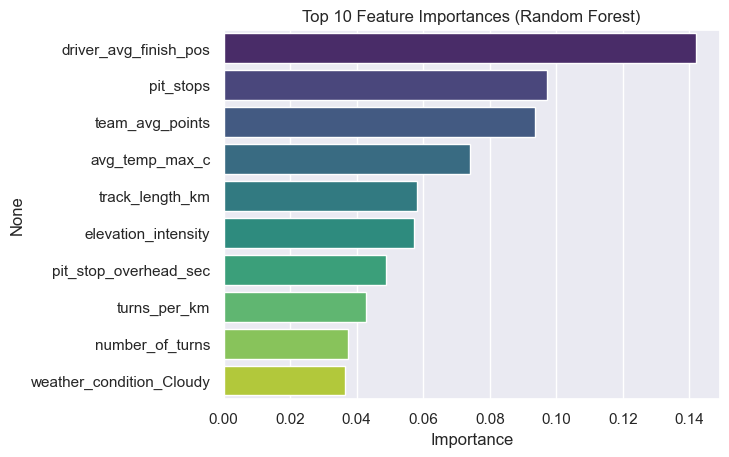

In [7]:
importances = rf_model.named_steps['regressor'].feature_importances_
cat_encoder = rf_model.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_features = cat_encoder.get_feature_names_out(cat_features).tolist()
feature_names = num_features + encoded_cat_features

feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)

sns.barplot(x=feat_importances.values, y=feat_importances.index, palette='viridis')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.show()

## 7. Save the Best Model
We save our Random Forest model to be utilized for future predictions.

In [8]:
joblib.dump(rf_model, 'f1_lap_time_estimator.joblib')
print("Model saved as 'f1_lap_time_estimator.joblib'")

Model saved as 'f1_lap_time_estimator.joblib'
